                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976   

   yr_renovated                    str

C:\Users\DELL\AppData\Local\Temp\ipykernel_4928\1262890715.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in data.select_dtypes(include='object').columns:


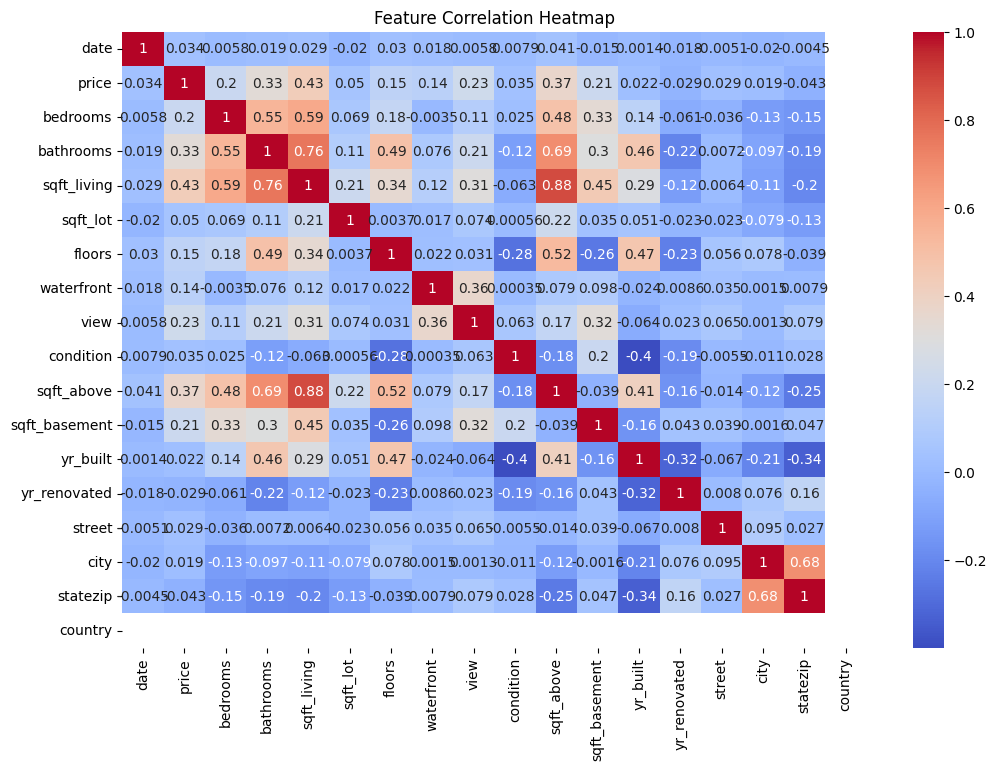


Mean Absolute Error: 207816.82941665532

RMSE: 993048.575350367

R2 Score: 0.03304504390209173


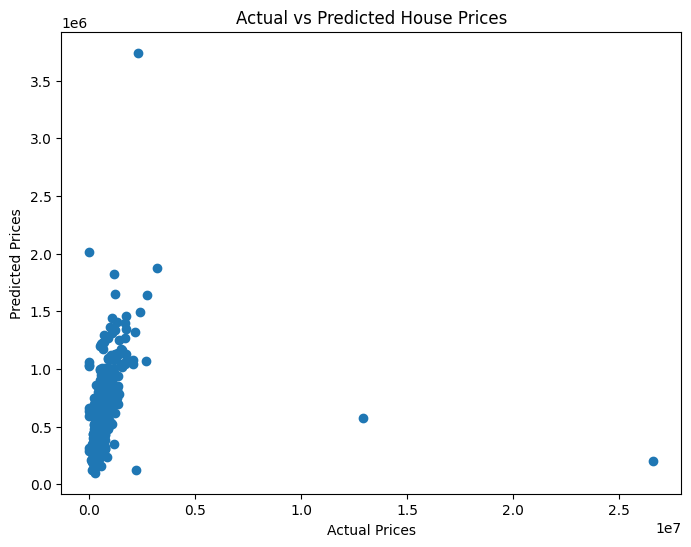


Actual vs Predicted Prices:
   Actual Price  Predicted Price
0      544000.0     3.160647e+05
1           0.0     3.152174e+05
2     1712500.0     1.071221e+06
3      365000.0     5.601984e+05
4      275000.0     3.858918e+05

Feature Importance:
          Feature    Coefficient
3     sqft_living  136362.555487
9      sqft_above  119688.960759
10  sqft_basement   60657.163318
7            view   37608.573316
14           city   35787.022890
5          floors   33367.871595
6      waterfront   32063.603927
2       bathrooms   27907.832903
8       condition   20456.919669
12   yr_renovated    9059.755232
13         street    7222.362873
0            date    1700.092928
16        country       0.000000
4        sqft_lot  -19063.437262
15       statezip  -28506.294446
1        bedrooms  -56040.155381
11       yr_built  -74882.986677


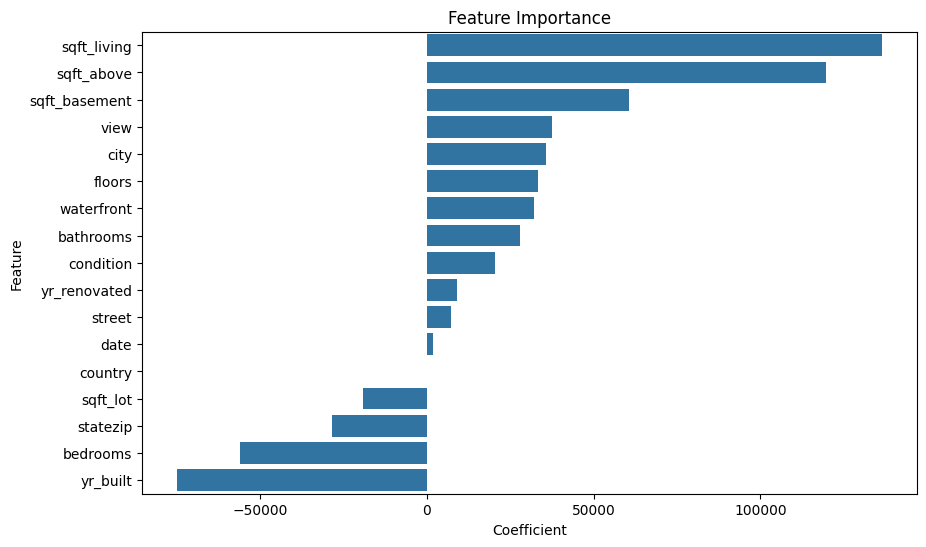

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

data = pd.read_csv("data.csv")

print(data.head())

print("\nMissing Values:")
print(data.isnull().sum())

for col in data.select_dtypes(include='object').columns:
    data[col] = pd.Categorical(data[col]).codes

data = data.fillna(data.median(numeric_only=True))

plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

X = data.drop('price', axis=1)
y = data['price']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("\nMean Absolute Error:", mae)

print("\nRMSE:", rmse)

print("\nR2 Score:", r2)

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()

comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

print("\nActual vs Predicted Prices:")
print(comparison.head())

importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

print("\nFeature Importance:")
print(importance)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")

plt.show()